In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Verificando os dados

In [35]:
df = pd.read_excel("/content/Vendas - Ecommerce.xlsx")

df.info()
print("\nNúmero de linhas com valor nulo:")
print(df.isnull().sum())

print("Número de linhas duplicadas:", df.duplicated().sum())

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID da Venda          185 non-null    int64         
 1   Data da Venda        185 non-null    datetime64[ns]
 2   ID Produto           185 non-null    int64         
 3   Produto e Categoria  185 non-null    object        
 4   Quantidade           185 non-null    int64         
 5   Preço Unitário       185 non-null    float64       
 6   -                    0 non-null      float64       
 7   Preço Total          185 non-null    float64       
 8   Método de Pagamento  185 non-null    object        
 9   Canal                185 non-null    object        
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 14.6+ KB

Número de linhas com valor nulo:
ID da Venda              0
Data da Venda            0
ID Produto               0
Produto e Cate

,ID da Venda,Data da Venda,ID Produto,Produto e Categoria,Quantidade,Preço Unitário,-,Preço Total,Método de Pagamento,Canal
0,1,2023-07-01 08:30:49,101,"Guarda-roupa,Móveis",5,249.27,NaN,1246.35,PIX,Website
1,2,2023-06-02 11:59:00,102,"Livro de História,Livros",9,590.11,NaN,5310.99,CARTÃO DE CRÉDITO,Website
2,3,2023-07-30 09:18:29,103,"Calça Jeans,Roupas",4,120.26,NaN,481.04,PIX,Website
3,4,2023-05-10 06:09:06,104,"Quebra-cabeça,Brinquedos",10,599.06,NaN,5990.60,CARTÃO DE CRÉDITO,Website
4,5,2023-08-11 00:01:14,105,"Livro de Receitas,Livros",3,600.94,NaN,1802.82,PIX,Website


Limpeza e Tratamento dos dados

In [36]:
df.dropna(axis=1, inplace=True)
df.columns = [
    "id_venda",
    "data_venda",
    "id_produto",
    "produto_categoria",
    "quantidade",
    "preco_unitario",
    "preco_total",
    "metodo_pagamento",
    "canal"
]

In [37]:
df["data_venda"] = pd.to_datetime(df["data_venda"])

df["ano"] = df["data_venda"].dt.year
df["mes"] = df["data_venda"].dt.month
df["dia"] = df["data_venda"].dt.day

df["produto"] = df["produto_categoria"].str.split(',').str[0]
df["categoria"] = df["produto_categoria"].str.split(',').str[1]

In [38]:
df.drop("produto_categoria", axis=1, inplace=True)
df.drop("data_venda", axis=1, inplace=True)

In [50]:
df["metodo_pagamento"] = df["metodo_pagamento"].astype(str)
df["canal"] = df["canal"].astype(str)
df["produto"] = df["produto"].astype(str)
df["categoria"] = df["categoria"].astype(str)

Análise Exploratória (EDA)

Quantidade de vendas por categoria:
      categoria  quantidade
0       Roupas         169
1   Brinquedos         196
2       Móveis         201
3       Livros         216
4  Eletrônicos         237
Quantidade de vendas por produto:
                   produto  quantidade
0                 Cadeira          10
1           Blusa de Frio          18
2                Carrinho          20
3                  Shorts          33
4                 Pelúcia          35
5                Camiseta          35
6           Quebra-cabeça          37
7              Smartphone          37
8                Notebook          38
9             Calça Jeans          39
10                   Mesa          39
11        Livro de Ficção          41
12      Jogo de Tabuleiro          41
13      Livro de Receitas          43
14      Livro de História          43
15                  Mangá          43
16                Vestido          44
17                   Sofá          45
18  Revista em Quadrinhos          46
19    

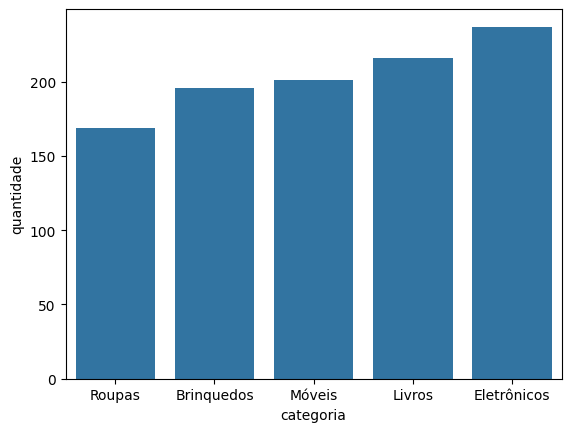

In [75]:

categoria_vendas = df.groupby("categoria")["quantidade"].sum().sort_values().reset_index()
produtos_vendas = df.groupby("produto")["quantidade"].sum().sort_values().reset_index()
top_10_produtos = df.groupby("produto")["quantidade"].sum().sort_values(ascending=False).head(10).reset_index()
print("Quantidade de vendas por categoria:\n", categoria_vendas)
print("Quantidade de vendas por produto:\n", produtos_vendas)

sns.barplot(
    x="categoria",
    y="quantidade",
    data=categoria_vendas
)

plt.show()

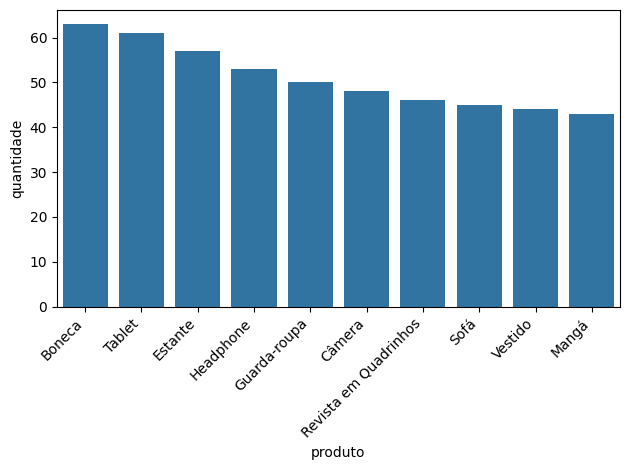

In [82]:
sns.barplot(
    x="produto",
    y="quantidade",
    data=top_10_produtos
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()